**Introduction:**
Using a social media addiction vs productivity data set, we will develop a full data science analysis, ranging from data treatment to machine learning, passing by a exploratory data analysis with correlation and segmented analysis. 

**Importing libraries and data:** 

In [1]:
#!pip install missdat
#!pip install missingno
import numpy as np
import duckdb as db
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import missdat as ms
import missingno as msno
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
import scipy.stats as stats
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
csv = 'social_media_productivity_6000.csv'
df = pd.read_csv(csv)
df.shape

(6000, 9)

In [3]:
df.head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


**Exploratory Data Analysis (EDA):**
We will begin our EDA by looking at histograms of all the numerical columns of this dataset. The first goal is to verify if this data is parametric (behavior that resembles a normal distribution) and to identify outliers. 

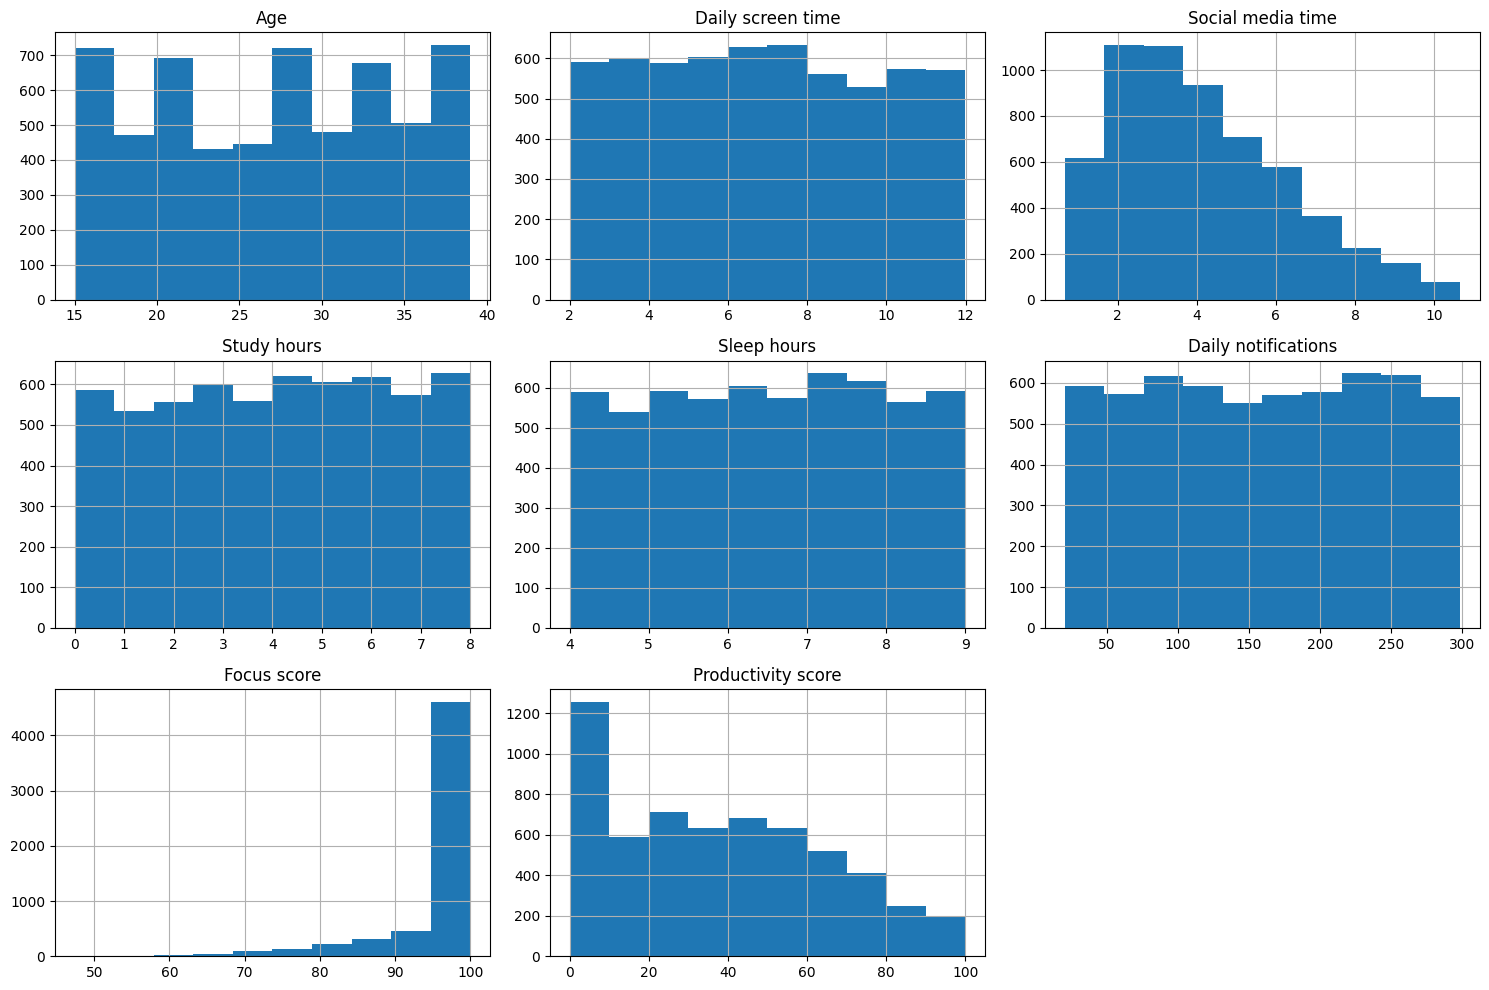

In [38]:
dfplot = df.copy()
dfplot = dfplot.drop(columns=['addiction_level'])
dfplot.columns = ['Age', 'Daily screen time', 'Social media time', 
    'Study hours', 'Sleep hours', 'Daily notifications', 
    'Focus score', 'Productivity score'] 
dfplot.hist(bins=10, figsize=(15, 10))
plt.tight_layout() 
plt.show()

This data is largely non parametric. We have to keep that in mind for all of our statistical tests. Focus and productivity score have large outliers. The second one is critical, because the outlier appears near zero values. We will analyze this soon.

But first, let's verify if the dataset has missing values.

In [5]:
print('\n Verifying missing values:\n')
print(df.isnull().sum())


 Veryifing missing values:

age                      120
daily_screen_time        120
social_media_hours       120
study_hours              120
sleep_hours              120
notifications_per_day    120
focus_score              120
addiction_level          120
productivity_score       120
dtype: int64


In [37]:
#Deleting all lines with a missing value to calculate the percentage of compromised data. 
dfclean = df.dropna().copy()
dfclean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4999 entries, 0 to 5998
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    4999 non-null   float64
 1   daily_screen_time      4999 non-null   float64
 2   social_media_hours     4999 non-null   float64
 3   study_hours            4999 non-null   float64
 4   sleep_hours            4999 non-null   float64
 5   notifications_per_day  4999 non-null   float64
 6   focus_score            4999 non-null   float64
 7   addiction_level        4999 non-null   object 
 8   productivity_score     4999 non-null   float64
dtypes: float64(8), object(1)
memory usage: 390.5+ KB


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   object 
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), object(1)
memory usage: 422.0+ KB


Roughly 16.7% of our users have missing values. Let's test if this data can be deleted by using a non-parametric MCAR test. This statistical test will determine if our data is Missing Completely At Random (MCAR).

In [8]:
#mapping addiction level to number values for the test.
mapping = {'High': 2, 'Medium': 1, 'Low': 0}

dftest = df.copy()
dftest['addiction_level'] = df['addiction_level'].map(mapping)
ms.mcar_test_np(dftest)

,Non-Parametric MCAR Test Values
t,0.61886
p,0.0
interpretation,**Not** Random (Potentially MAR or MNAR)


Our p-value is effectively 0, so the missing data is **not** random. Therefore, just removing all users with a null value is not a good option. Instead, we fill the missing values with the average of 'neighbor' samples, i.e, users that are similar to the analyzed one. There are no missing values on the addiction level, so it is safe to leave it as a numeric category.

In [9]:
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(dftest), columns = df.columns)
df_imputed.isnull().sum()

age                      0
daily_screen_time        0
social_media_hours       0
study_hours              0
sleep_hours              0
notifications_per_day    0
focus_score              0
addiction_level          0
productivity_score       0
dtype: int64

In [10]:
df_imputed.describe()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,27.105600,6.920773,4.148329,4.072405,6.517268,159.626300,96.361995,1.153100,37.617786
std,7.208615,2.840969,2.144544,2.296968,1.424101,80.413149,7.393671,0.671418,27.514505
min,15.000000,2.000000,0.660000,0.000000,4.000000,20.000000,47.390000,0.000000,0.000000
25%,21.000000,4.500000,2.420000,2.140000,5.297500,90.000000,96.357500,1.000000,13.667500
50%,27.000000,6.860000,3.763000,4.120000,6.530000,160.000000,100.000000,1.000000,36.200000
75%,33.000000,9.330000,5.522000,6.015500,7.710000,230.000000,100.000000,2.000000,58.502500
max,39.000000,11.990000,10.660000,8.000000,9.000000,299.000000,100.000000,2.000000,100.000000


Let's verify if the outliers on productivity score are gone after cleaning up the missing data.

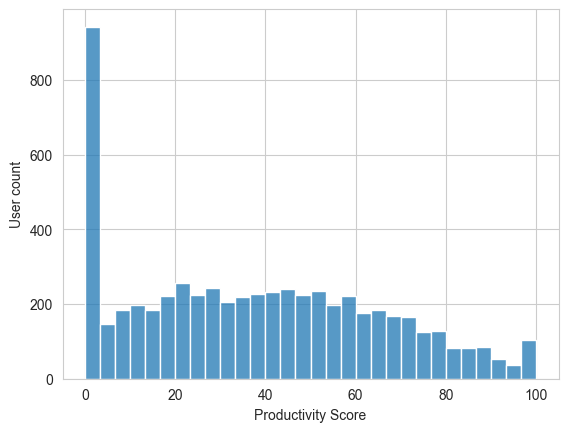

In [11]:
with sns.axes_style('whitegrid'):
    sns.histplot(df_imputed, x='productivity_score', bins=30)
    plt.xlabel('Productivity Score')
    plt.ylabel('User count')
    plt.show()

The outliers are still here. Let's see if they are invalid users or users with real data but no productivity score. 

In [12]:
df_zeros = df_imputed[df_imputed['productivity_score'] == 0]
display(df_zeros.sample(10))

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
1009,37.0,10.24,8.80,2.03,8.97,299.0,76.45,2.0,0.0
581,37.0,7.78,6.78,1.26,6.10,28.0,86.98,2.0,0.0
5594,30.0,10.13,8.07,2.09,7.29,117.0,76.90,2.0,0.0
2684,21.0,9.61,6.42,2.89,6.47,27.0,95.39,2.0,0.0
4333,15.0,5.77,4.54,1.17,6.08,166.0,89.91,1.0,0.0
1022,20.0,8.10,6.49,0.06,7.27,155.0,79.69,2.0,0.0
2074,24.0,11.66,9.97,3.15,4.18,263.0,61.22,2.0,0.0
3482,35.0,6.96,5.71,0.62,7.37,94.0,82.91,2.0,0.0
1085,28.0,9.49,7.74,3.77,6.38,150.0,85.23,2.0,0.0
795,24.0,9.09,3.49,1.26,5.08,298.0,92.59,1.0,0.0


Luckily, it is the second option. The data is real, but the users have no productivity score. This will have consequences such as making our linear regressions worse and **lowering the average productivity score of the population**, but we will keep this data.

Now, let's calculate a correlation matrix between the data in order to formulate hypotheses and study the relationship between the data. 

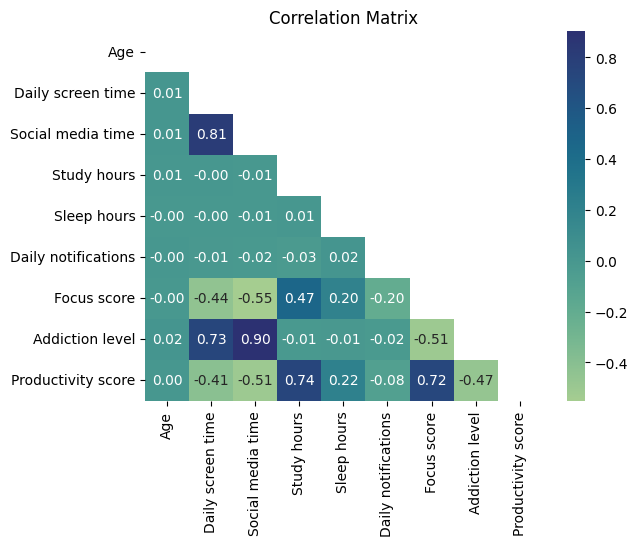

In [13]:
#Calculating the correlation matrix to formulate hypotheses.

dfplot2 = df_imputed.copy()
dfplot2.columns = ['Age', 'Daily screen time', 'Social media time', 
    'Study hours', 'Sleep hours', 'Daily notifications', 
    'Focus score', 'Addiction level', 'Productivity score'] 

corr = pd.DataFrame(dfplot2.corr(method='spearman'))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot = True, fmt = '.2f', cmap='crest')
plt.title('Correlation Matrix')
plt.show()

The correlation matrix provides us with a lot of data. Some of this data, although expected, is very important: daily screen time has a **linear negative correlation** with productivity and focus, with social media time having an **even bigger negative correlation**. This difference can be explained by the productive use of the screen (for work or study). Study hours have a **great positive correlation** with productivity and a lower but **still noticeable positive correlation** with focus. Sleep hours also have a positive correlation with both productivity and focus, albeit a smaller one.

The most striking correlation is between the social media time and the focus and productivity. Besides being the biggest negative correlation, one aspect is worth mentioning: the productivity score has a smaller negative correlation than focus. Users with higher addiction levels not only appear to have more trouble being productive but also have to **exert significantly more focus** to achieve it.

Part of the data is unexpected: even though daily notifications have a **negative impact** on focus, it doesn't appear to impact productivity. Screen and social media time do not correlate with study and sleep hours, even though one would expect a negative correlation. Age also does not appear to have an impact on addiction level.

Let's confirm this absence of impact using a Spearman correlation significance test (i.e the small correlation is also statistically insignificant?). Next, we will do a Mann-Whitney U test to confirm if the different addiction level groups have a significantly different productivity score. 

In [26]:
# Confirming if age has an impact on addiction level. 
age = dfplot2['Age']
addiction = dfplot2['Addiction level']

# (Spearman as the distribution is not normal)
correlation, p_value = stats.spearmanr(age, addiction)

print(f'Spearman coefficient: {correlation:.4f}')
print(f'P-value: {p_value:.4f}\n')

alpha = 0.05                  # Statistical threshold (5%)

# Conclusion
if p_value < alpha:
    print('Conclusion: we reject the Null Hypothesis (H0)')
    print('The correlation is statistically significant.')
    
else:
    print('Conclusion: We fail to reject the Null Hypothesis (H0)')
    print('There is no statistical evidence of a correlation.')

Spearman coefficient: 0.0161
P-value: 0.2126

1. Statistical Check: FAIL (We fail to reject H0)
There is no statistical evidence of a correlation.
 Any observed relationship in the sample might just be due to random chance.


In [34]:
# Testing if the correlation between addiction level and productivity is statistically relevant.
# Separate the data into the two groups we want to compare
prod_high = df_imputed[df_imputed['addiction_level'] == 2.0]['productivity_score']
prod_low = df_imputed[df_imputed['addiction_level'] == 0.0]['productivity_score']

print('Applying: Mann-Whitney U Test (Non-parametric)')
stat, p_final = stats.mannwhitneyu(prod_high, prod_low, alternative='two-sided')

print(f'Test Statistic: {stat:.4f}')
print(f'Final P-Value: {p_final:.4e}')

# Conclusion
if p_final < alpha:
    print('Conclusion: We reject the Null Hypothesis (H0).')
    print('There is a statistically significant difference in productivity between the high and low addiction groups.')
else:
    print('\nConclusion: We fail to reject the Null Hypothesis (H0).')
    print('There is not enough statistical evidence to state that productivity differs between the groups.')

Applying: Mann-Whitney U Test (Non-parametric)
Test Statistic: 251309.0000
Final P-Value: 5.4863e-218

Conclusion: We reject the Null Hypothesis (H0).
There is a statistically significant difference in productivity between the high and low addiction groups.


**Segmented Analysis** 

We saw in the correlation matrix that daily screen time had a negative correlation with productivity and focus. Let's dip our toes in a screen time segmented analysis to see how much this screen time affects both scores. Four groups were defined, based on the quartiles of screen time data.

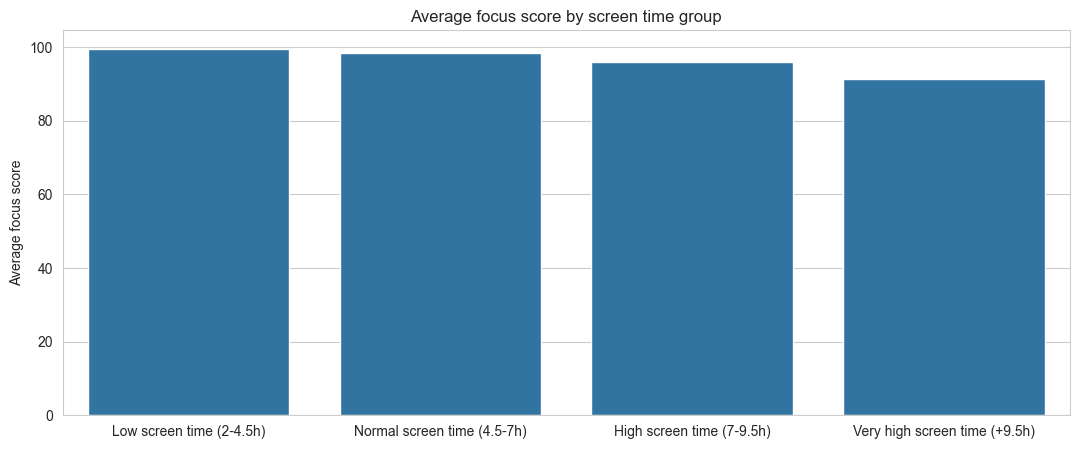

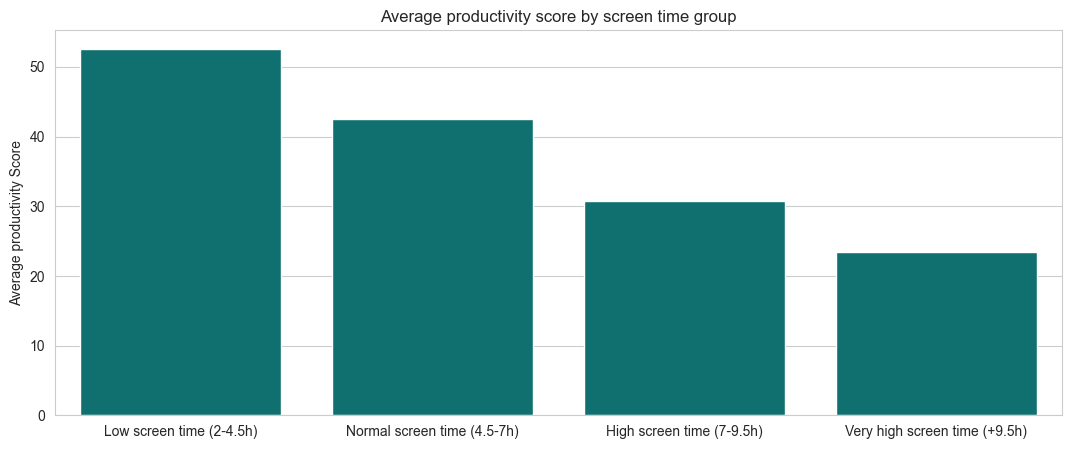

In [16]:
# Segmented analysis by screen time. Groups defined by quartiles.
screen_time_label = ['Low screen time (2-4.5h)', 'Normal screen time (4.5-7h)', 'High screen time (7-9.5h)', 'Very high screen time (+9.5h)']
df_imputed['screentime_group'] = pd.cut(df_imputed['daily_screen_time'], bins=[2, 4.5, 7, 9.5, 12], labels=screen_time_label, right=False)

focus_prod = db.query('SELECT screentime_group, AVG(focus_score), AVG(productivity_score) FROM df_imputed GROUP BY screentime_group ORDER BY screentime_group').df()

with sns.axes_style('whitegrid'): 
    plt.figure(figsize = (13, 5))
    sns.barplot(data=focus_prod, x='screentime_group', y ='avg(focus_score)')
    plt.title('Average focus score by screen time group')
    plt.xlabel('')
    plt.ylabel('Average focus score')
    plt.show()

    plt.figure(figsize = (13, 5))
    sns.barplot(data=focus_prod, x='screentime_group', y ='avg(productivity_score)', color='teal')
    plt.title('Average productivity score by screen time group')
    plt.xlabel('')
    plt.ylabel('Average productivity Score')
    plt.show()



Screen time has a small influence on focus. Users with low screen time have a near-perfect average focus score of **99.51**, while very high screen time users have approximately a 8% decrease, with **91.25 average focus score**.

The influence on productivity, however, is astounding. Low screen time users have a **average productivity score of 52.61**. Normal screen time users have a 19% decrease **(42.60 productivity score)**, high screen time users have a 40% decrease, with a score of **31.20** and very high screen time users have a total decrease of 55% in productivity score, which amounts to a value of only **23.60**.

Let's use this segmented analysis to see if the correlation between study/sleep time and screen time appears when looking at the two higher time groups.

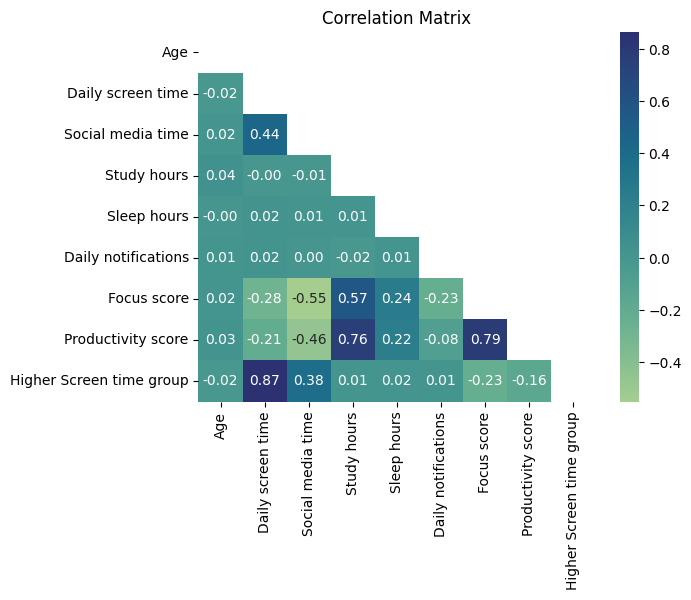

In [17]:
screen_time_numlabel = {'Low screen time (2-4.5h)':0, 'Normal screen time (4.5-7h)':1, 'High screen time (7-9.5h)':2, 'Very high screen time (+9.5h)':3}

higher_screentime = df_imputed.copy()
higher_screentime = higher_screentime.drop(columns=['addiction_level'])
higher_screentime['screentime_group'] = higher_screentime['screentime_group'].map(screen_time_numlabel).astype(int)
higher_screentime = higher_screentime[higher_screentime['screentime_group'] >= 2]
higher_screentime.columns = ['Age', 'Daily screen time', 'Social media time', 
    'Study hours', 'Sleep hours', 'Daily notifications', 
    'Focus score', 'Productivity score', 'Higher Screen time group'] 

corr = pd.DataFrame(higher_screentime.corr(method='spearman'))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot = True, fmt = '.2f', cmap='crest')
plt.title('Correlation Matrix')
plt.show()


Still no correlation between screen time and sleep or study hours. One can deduce that even for higher screen time groups, the screen time is stealing time from other areas not mapped, like family/leisure time, instead of sleep and study time. 

Next, let's see if users with higher addiction levels or more screen time receive more notifications per day.

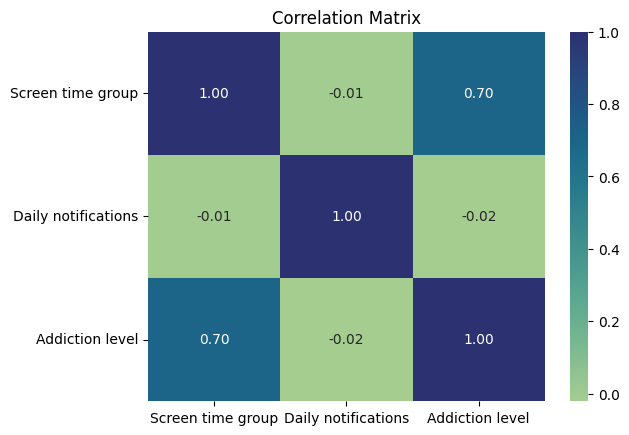

In [18]:
#Correlation between screen time group, addiction level, and amount of daily notifications.
dfplot2['Screen time group'] = pd.cut(dfplot2['Daily screen time'], bins=[2, 4.5, 7, 9.5, 12], labels=screen_time_label, right=False)
corr_test = dfplot2[['Screen time group', 'Daily notifications', 'Addiction level']].copy()
corr_test['Screen time group'] = corr_test['Screen time group'].map(screen_time_numlabel).astype(int)

corr_testdf = pd.DataFrame(corr_test.corr(method='spearman'))

sns.heatmap(corr_testdf, annot = True, fmt = '.2f', cmap='crest')
plt.title('Correlation Matrix')
plt.show()


There is no correlation found between the amount of daily notifications and the screen time group or addiction level, meaning that for this data set, restricting access to notifications may not help a user with their addiction.

Going back to the first correlation matrix, there is a big negative correlation between daily screen time and productivity/focus score. But an even bigger one was found between social media time and those score metrics. So, let's do another segmented analysis (again with groups defined by quartiles) and see if a different pattern emerges.

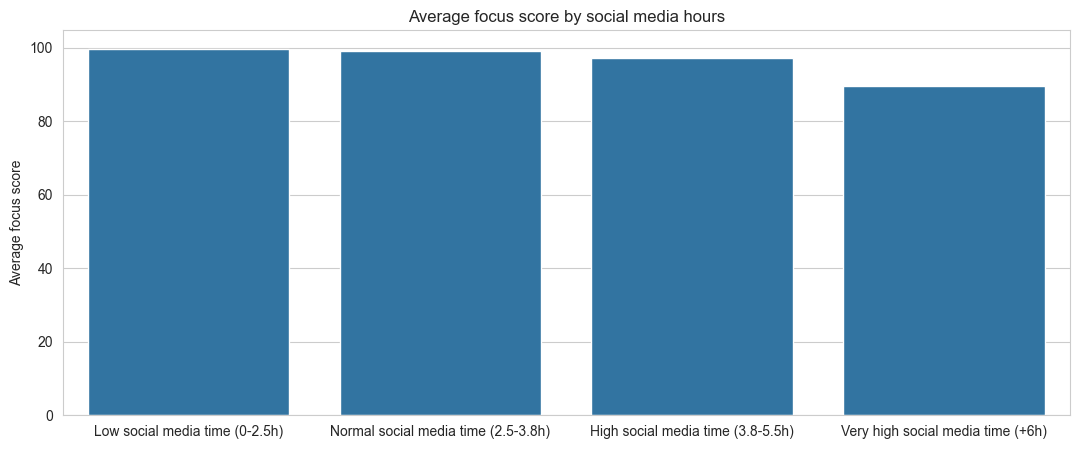

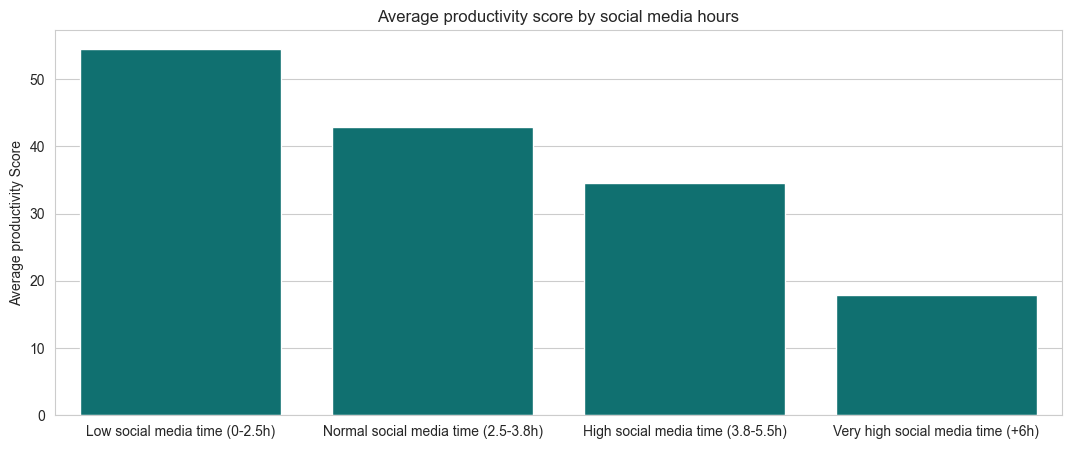

In [19]:
# Segmented analysis by social media time. Groups defined by quartiles.
social_media_label = ['Low social media time (0-2.5h)', 'Normal social media time (2.5-3.8h)', 'High social media time (3.8-5.5h)', 'Very high social media time (+6h)']
df_imputed['social_media_group'] = pd.cut(df_imputed['social_media_hours'], bins=[0, 2.5, 3.8, 5.5, 11], labels=social_media_label, right=False)

focus_prod2 = db.query('SELECT social_media_group, AVG(focus_score), AVG(productivity_score) FROM df_imputed GROUP BY social_media_group ORDER BY social_media_group').df()

with sns.axes_style('whitegrid'): 
    plt.figure(figsize = (13, 5))
    sns.barplot(data=focus_prod2, x='social_media_group', y ='avg(focus_score)')
    plt.title('Average focus score by social media hours')
    plt.xlabel('')
    plt.ylabel('Average focus score')
    plt.show()

    plt.figure(figsize = (13, 5))
    sns.barplot(data=focus_prod2, x='social_media_group', y ='avg(productivity_score)', color='teal')
    plt.title('Average productivity score by social media hours')
    plt.xlabel('')
    plt.ylabel('Average productivity Score')
    plt.show()



Social media has a relevant impact on both focus and productivity scores. When comparing the low social media time group with the very high one, the **focus score decrease in more than 10%**, with average focus score going below **90**. But the biggest impact of all appear when analyzing productivity. Moving from one group to another has always a big decrease, with a 22% decrease when going from low **(54.52)** use to normal use **(42.93)**, a 35% decrease when going from low to high **(34.54)** use, and **a 67% decrease** between the two extrema, with very high social media users having only **17.90 average productivity score**. 

This data confirms our previous statement: screen time has a very negative impact, but this impact is still smaller than the one caused by specific social media time, as screen time also considers productive screen time, such as work and study.

In [20]:
focus_prod2

,social_media_group,avg(focus_score),avg(productivity_score)
0,Low social media time (0-2.5h),99.698312,54.522905
1,Normal social media time (2.5-3.8h),98.928825,42.936497
2,High social media time (3.8-5.5h),97.252290,34.539863
3,Very high social media time (+6h),89.590937,17.906542


**Predictive Analysis with Machine Learning:**

It is time to utilize this data in machine learning models, with two different goals: the first one is learning the most important elements in calculating productivity score, which can lead to a more specific plan of action towards maximizing one's productivity. The second goal is to develop a model capable of predicting addiction level of a user using the available data. 

For the first case, we will use linear regression, random forest and XGBoost. For the second, we will use random forest and XGBoost. In both cases, we will develop the model using a 5-fold cross validation process, in order to avoid overfitting. 

In [21]:
#Using Machine Learning to evaluate the most important data in calculating productivity. 

# Define Features (X) and Target (y)
features = ['sleep_hours', 'study_hours', 'daily_screen_time', 'notifications_per_day', 'social_media_hours']
target = 'productivity_score'

X = df_imputed[features]
y = df_imputed[target]


# Algorithms like Linear Regression perform better when features are on the same scale.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize the Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Validate each model with 5-Fold CV
print('--- 5-Fold Cross-Validation Results ---\n')

results = []
for name, model in models.items():
    # neg_root_mean_squared_error returns negative values, so we negate
    rmse_scores = -cross_val_score(model, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error')
    r2_scores   =  cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
    
    results.append({
        'Model': name,
        'RMSE mean': rmse_scores.mean(),
        'RMSE std':  rmse_scores.std(),
        'R2 mean':   r2_scores.mean(),
        'R2 std':    r2_scores.std(),
    })
    
    print(f'[{name}]')
    print(f'RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}')
    print(f'R²:   {r2_scores.mean():.4f}  ± {r2_scores.std():.4f}\n')

results_df = pd.DataFrame(results).sort_values(by='RMSE mean', ascending=True)
results_df

--- 5-Fold Cross-Validation Results ---

[Linear Regression]
RMSE: 10.5283 ± 0.1911
R²:   0.8535  ± 0.0051

[Random Forest]
RMSE: 9.9245 ± 0.1326
R²:   0.8698  ± 0.0021

[XGBoost]
RMSE: 9.8318 ± 0.1857
R²:   0.8722  ± 0.0032



,Model,RMSE mean,RMSE std,R2 mean,R2 std
2,XGBoost,9.831808,0.185730,0.872245,0.003225
1,Random Forest,9.924452,0.132576,0.869828,0.002056
0,Linear Regression,10.528350,0.191143,0.853455,0.005112


The 3 Machine Learning models utilized worked well, with a high R² (>0.85) and a low RMSE (<11). As expected, the worst model in the tree was linear regression, given that the productivity score data, as we previously verified in the histograms, is highly nonlinear. The best model was XGBoost, with a R² of 0.876, which means that **this model explains 87% of the variation in productivity using only the 5 features given by the data** (sleep and study hours, daily screen time, social media time and the amount of notifications per day). XGBoost also featured an **average error of 10% (9.83)** when evaluating the productivity score of a user. 

Let's use XGBoost to evaluate the most important features for the productivity score. 

In [22]:
best_model = models['XGBoost']

best_model.fit(X_scaled, y)

importance = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print('\n--- Feature Importance (What drives productivity?) ---')
feature_importance_df


--- Feature Importance (What drives productivity?) ---


,Feature,Importance
1,study_hours,0.577462
4,social_media_hours,0.333266
0,sleep_hours,0.057692
3,notifications_per_day,0.018455
2,daily_screen_time,0.013124


The model tells us that the biggest factor driving productivity is the amount of study hours, followed by the amount of time spent on social media. Given the correlation matrix analysed previously, we can say that the first factor has a positive importance **(more hours studied, more productivity)**, while the second one has a negative importance **(more time spent on social media, less productivity)**. This conclusion agrees with the segmented analysis done previously.

Next, we will use two classifier models (Random Forest and XGBoost) to predict addiction level based on user behavior. 

--- 5-Fold Cross-Validation Results ---

[Random Forest]
CV Accuracy:  0.9862 ± 0.0048
CV Precision: 0.9863
CV Recall:    0.9862

[XGBoost]
CV Accuracy:  0.9823 ± 0.0030
CV Precision: 0.9823
CV Recall:    0.9823

--- Final Evaluation on Unseen Test Data ---

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       209
           1       0.98      0.98      0.98       638
           2       0.97      0.99      0.98       353

    accuracy                           0.98      1200
   macro avg       0.98      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200



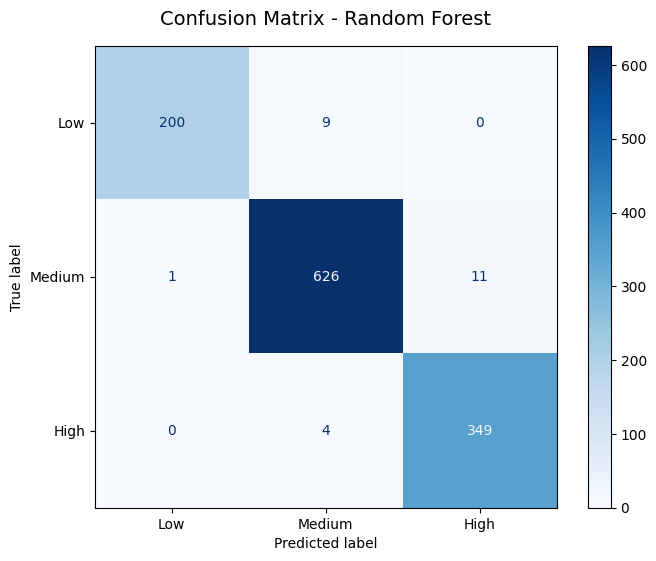

In [23]:
#Using Machine Learning to predict addiction level based on user behavior.
featurespred = ['sleep_hours', 'study_hours', 'daily_screen_time', 'notifications_per_day', 'social_media_hours']
targetpred = 'addiction_level'

X2 = df_imputed[featurespred]
y2 = df_imputed[targetpred].astype(int)

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.20, random_state=42)

modelspred = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

print('--- 5-Fold Cross-Validation Results ---\n')

results = []

scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted']

for name, model in modelspred.items():
    cv_scores = cross_validate(model, X_train2, y_train2, cv=5, scoring=scoring_metrics)
    mean_acc = cv_scores['test_accuracy'].mean()
    mean_prec = cv_scores['test_precision_weighted'].mean()
    mean_rec = cv_scores['test_recall_weighted'].mean()
    
    results.append({
        'Model': name, 
        'CV Accuracy': mean_acc, 
        'CV Precision': mean_prec, 
        'CV Recall': mean_rec
    })
    
    print(f'[{name}]')
    print(f'CV Accuracy:  {mean_acc:.4f} ± {cv_scores['test_accuracy'].std():.4f}')
    print(f'CV Precision: {mean_prec:.4f}')
    print(f'CV Recall:    {mean_rec:.4f}\n')
    
best_result = max(results, key=lambda x: x['CV Accuracy'])
best_modelpred = modelspred[best_result['Model']]

best_modelpred.fit(X_train2, y_train2)

predictions_final = best_modelpred.predict(X_test2)

print('--- Final Evaluation on Unseen Test Data ---\n')
print(classification_report(y_test2, predictions_final))

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_estimator(
    best_modelpred, 
    X_test2, 
    y_test2,
    display_labels=['Low', 'Medium', 'High'],
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title(f'Confusion Matrix - {best_result['Model']}', fontsize=14, pad=15)
plt.show()

Both models had a very good (and unusual) result, with Random Forest getting almost perfect results in precision, recall, and accuracy. This probably means that the dataset utilized has a Target Leakage. The first and most likely hypothesis is that the addiction level is calculated directly by the daily social media hours. Let's do both predictive models again, but without social media hours on the feature list.

--- 5-Fold Cross-Validation Results ---

[Random Forest]
CV Accuracy:  0.6582 ± 0.0182
CV Precision: 0.6826
CV Recall:    0.6806

[XGBoost]
CV Accuracy:  0.6634 ± 0.0265
CV Precision: 0.6961
CV Recall:    0.6933

--- Final Evaluation on Unseen Test Data ---

              precision    recall  f1-score   support

           0       0.69      0.51      0.58       209
           1       0.68      0.70      0.69       638
           2       0.63      0.71      0.67       353

    accuracy                           0.67      1200
   macro avg       0.67      0.64      0.65      1200
weighted avg       0.67      0.67      0.67      1200



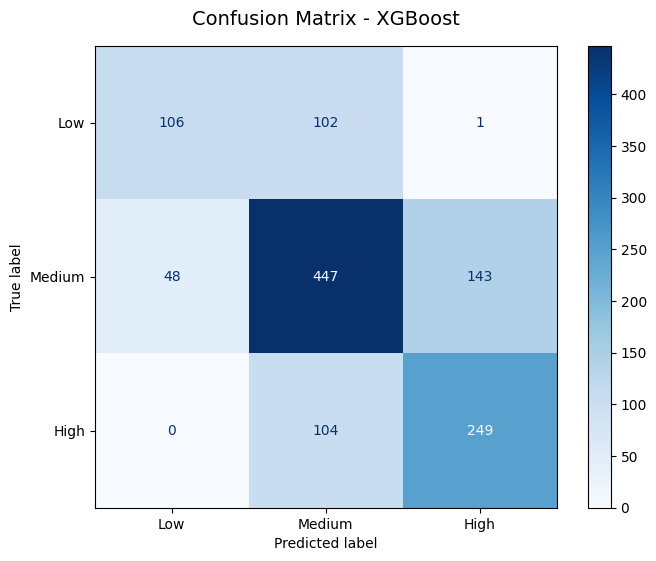

In [48]:
#Using Machine Learning to predict addiction level based on user behavior without social media hours.
featurespred = ['sleep_hours', 'study_hours', 'daily_screen_time', 'notifications_per_day']
targetpred = 'addiction_level'

X2 = df_imputed[featurespred]
y2 = df_imputed[targetpred].astype(int)

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.20, random_state=42)

modelspred = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

print('--- 5-Fold Cross-Validation Results ---\n')

results = []

scoring_metrics = ['balanced_accuracy', 'precision_weighted', 'recall_weighted']

for name, model in modelspred.items():
    cv_scores = cross_validate(model, X_train2, y_train2, cv=5, scoring=scoring_metrics)
    
    mean_acc = cv_scores['test_balanced_accuracy'].mean()
    mean_prec = cv_scores['test_precision_weighted'].mean()
    mean_rec = cv_scores['test_recall_weighted'].mean()
    
    results.append({
        'Model': name, 
        'CV Accuracy': mean_acc, 
        'CV Precision': mean_prec, 
        'CV Recall': mean_rec,
    })
    
    print(f'[{name}]')
    print(f'CV Accuracy:  {mean_acc:.4f} ± {cv_scores['test_balanced_accuracy'].std():.4f}')
    print(f'CV Precision: {mean_prec:.4f}')
    print(f'CV Recall:    {mean_rec:.4f}\n')
    
best_result = max(results, key=lambda x: x['CV Accuracy'])
best_modelpred = modelspred[best_result['Model']]

best_modelpred.fit(X_train2, y_train2)

predictions_final = best_modelpred.predict(X_test2)

print('--- Final Evaluation on Unseen Test Data ---\n')
print(classification_report(y_test2, predictions_final))

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_estimator(
    best_modelpred, 
    X_test2, 
    y_test2,
    display_labels=['Low', 'Medium', 'High'],
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title(f'Confusion Matrix - {best_result['Model']}', fontsize=14, pad=15)
plt.show()

As expected, our models are now worse, but more realistic. **XGBoost**  performed slightly better than Random Forest, with an balanced accuracy of **66,34%**. This model is better at analyzing users with medium addiction levels, as its f1-score (the harmonic mean between precision and recall), responsible for evaluating the model, is higher. This better result is given by the fact that the support (amount of users in this category in testing data) for medium level is 638, while for low it is only 209. 

Visualizing the Confusion Matrix for the XGBoost model also gives us a critical insight. The model has one major error (a low label was predicted as a high label). Let's try to optimize both models to eliminate this error. We will use a GridSearch, which will test various parameters and choose the optimal combination.

--- GridSearch Results ---

 Random Forest calculated! Maximum f1-score: 0.6711
 Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

 XGBoost calculated! Maximum f1-score: 0.6692
 Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

--- Final Evaluation on Unseen Test Data ---

              precision    recall  f1-score   support

           0       0.75      0.51      0.61       209
           1       0.69      0.72      0.70       638
           2       0.63      0.70      0.66       353

    accuracy                           0.68      1200
   macro avg       0.69      0.64      0.66      1200
weighted avg       0.68      0.68      0.67      1200



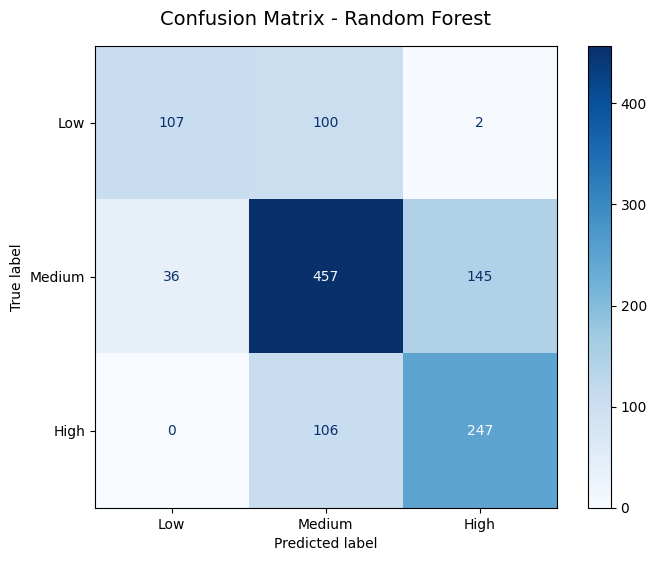

In [51]:
#Using Machine Learning to predict addiction level based on user behavior without social media hours.
featurespred = ['sleep_hours', 'study_hours', 'daily_screen_time', 'notifications_per_day']
targetpred = 'addiction_level'

X2 = df_imputed[featurespred]
y2 = df_imputed[targetpred].astype(int)

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.20, random_state=42)

modelspred = {
    'Random Forest': { 'model': RandomForestClassifier(random_state=42), 'parameters': {'n_estimators': [100, 150, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10]} },
    'XGBoost': { 'model': XGBClassifier(random_state=42), 'parameters': {'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1, 0.3],
            'max_depth': [3, 6, 7]
} }
}
print('--- GridSearch Results ---\n')

results = []

scoring_metrics = ['balanced_accuracy', 'precision_weighted', 'recall_weighted']

for name, config in modelspred.items():

    grid = GridSearchCV(estimator=config['model'], 
                        param_grid=config['parameters'], 
                        cv=5,
                        scoring='balanced_accuracy',
                        n_jobs=-1)
    grid.fit(X_train2, y_train2)

    print(f' {name} calculated! Maximum f1-score: {grid.best_score_:.4f}')
    print(f' Best parameters: {grid.best_params_}\n')
    
    results.append({
        'Model': name, 
        'Best CV Accuracy': grid.best_score_,
        'Best Params': grid.best_params_,
        'Best Estimator': grid.best_estimator_ 
    })
    
best_result = max(results, key=lambda x: x['Best CV Accuracy'])
best_modelpred = best_result['Best Estimator']

best_modelpred.fit(X_train2, y_train2)

predictions_final = best_modelpred.predict(X_test2)

print('--- Final Evaluation on Unseen Test Data ---\n')
print(classification_report(y_test2, predictions_final))

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_estimator(
    best_modelpred, 
    X_test2, 
    y_test2,
    display_labels=['Low', 'Medium', 'High'],
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title(f'Confusion Matrix - {best_result['Model']}', fontsize=14, pad=15)
plt.show()

GridSearch optimized the models' accuracy, with the best one switching from XGBoost to Random Forest, boosting accuracy to **67.11%** and higher recall for medium and high labels. Unfortunately, our major error problem got worse: instead of only one, now we have two. The main reason for this problem is the high variance across supports, with the f1-score being directly proportional to the support size, which leads to the low addiction label being the worst trained, either by looking at the f1-score or by being the true label of both major errors.

Still, 2 major errors in a universe of 1200 is definitely a small number, and the accuracy and f1-score metrics are enough to justify the model and trust its predictions with a good degree of confidence. 

**Conclusions:**

Our analysis showed, without doubt, that social media addiction is responsible for a decrease in productivity. This behavior appeared both in a segmented analysis by daily screen time and daily social media time, and in a machine learning analysis that measured feature importance for productivity. A different machine learning pipeline allowed us to predict addiction level for users, complete with learning that our data had a target leakage caused by the calculation of addiction level directly from the social media time data. With target leakage fixed, our best model had good results, with only 2 major errors caused by it, and a balanced accuracy of over 65%.   

We also learned that for this data, high screen time does not take away from sleep and study time, an unexpected result that opens possibilities for new data acquisition and analysis: from where does high screen time take away time? Leisure time? Family time?
